In [1]:
import sys
!{sys.executable} -m pip install nltk spacy tweet-preprocessor emoji matplotlib pandas --quiet
!{sys.executable} -m spacy download en_core_web_sm --quiet

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

import re
import emoji
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from nltk.tokenize import word_tokenize, TweetTokenizer
import spacy

nlp = spacy.load("en_core_web_sm")
print("All libraries loaded successfully!")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Manasi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Manasi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


All libraries loaded successfully!


In [1]:
social_media_posts = [
    "OMG!! Just saw @elonmusk tweet about #AI 🤖🔥 Can't believe it!! Check👉 https://t.co/xyz123",
    "loooooove this new #iPhone15 📱😍 @Apple never disappoints!! #Tech #Gadgets RT if u agree!!",
    "It's 2:30am & I'm still coding 😭💻 #DevLife #100DaysOfCode won't give up tho... #Python",
    "BREAKING: ChatGPT-5 released 🚀🚀 #OpenAI #ChatGPT visit👉https://openai.com/blog #MachineLearning",
    "can't even... my WiFi is soooo slow rn 😤😤 @ServiceProvider fix ur network plzzz #frustrated",
    "Just finished @coursera ML course 🎓✅ #MachineLearning #AI #DataScience feeling gr8!!",
    "w/o proper sleep u can't code well... trust me😪 #NightOwl cc: @dev_friends #coding",
    "Top 5 #NLP tools: 1)NLTK 2)SpaCy 3)HuggingFace 4)Gensim 5)Flair... thoughts?? #Python #AI",
]

print("Social Media Posts:")
print("=" * 60)
for i, post in enumerate(social_media_posts, 1):
    print(f"\nPost {i}: {post}")

Social Media Posts:

Post 1: OMG!! Just saw @elonmusk tweet about #AI 🤖🔥 Can't believe it!! Check👉 https://t.co/xyz123

Post 2: loooooove this new #iPhone15 📱😍 @Apple never disappoints!! #Tech #Gadgets RT if u agree!!

Post 3: It's 2:30am & I'm still coding 😭💻 #DevLife #100DaysOfCode won't give up tho... #Python

Post 4: BREAKING: ChatGPT-5 released 🚀🚀 #OpenAI #ChatGPT visit👉https://openai.com/blog #MachineLearning

Post 5: can't even... my WiFi is soooo slow rn 😤😤 @ServiceProvider fix ur network plzzz #frustrated

Post 6: Just finished @coursera ML course 🎓✅ #MachineLearning #AI #DataScience feeling gr8!!

Post 7: w/o proper sleep u can't code well... trust me😪 #NightOwl cc: @dev_friends #coding

Post 8: Top 5 #NLP tools: 1)NLTK 2)SpaCy 3)HuggingFace 4)Gensim 5)Flair... thoughts?? #Python #AI


In [4]:
import re

class SocialMediaTokenizer:
    """
    Rule-based tokenizer for social media text.
    Handles: URLs, mentions, hashtags, emojis, 
             elongated words, emoticons, contractions
    """

    PATTERNS = [
        ('URL',         r'https?://\S+|www\.\S+'),
        ('MENTION',      r'@\w+'),
        ('HASHTAG',      r'#\w+'),
        ('EMOJI',        r'[\U00010000-\U0010ffff]|[\u2600-\u27FF]|[\u2300-\u23FF]'),
        ('EMOTICON',     r'(?::|;|=)(?:-)?(?:\)|\(|D|P)|<3|</3'),
        ('TIME',         r'\b\d{1,2}:\d{2}(?:am|pm)?\b'),
        ('NUMBER',       r'\b\d+\b'),
        ('ELONGATED',    r'\b(\w)\1{2,}\w*\b'),        
        ('CONTRACTION',  r"\b\w+'\w+\b"),                 
        ('WORD',         r'\b\w+\b'),
        ('PUNCTUATION',  r'[^\w\s]'),
    ]

    def __init__(self):
        # Compiles the master regex pattern using the list above
        self.master_pattern = re.compile(
            '|'.join(f'(?P<{name}>{pat})' for name, pat in self.PATTERNS),
            re.UNICODE | re.IGNORECASE
        )

    def tokenize(self, text):
        tokens = []
        for match in self.master_pattern.finditer(text):
            token_type = match.lastgroup
            token_val  = match.group()
            tokens.append((token_val, token_type))
        return tokens

    def tokenize_simple(self, text):
        """Returns only token strings (no labels) for comparison"""
        return [val for val, _ in self.tokenize(text)]

    def normalize_elongated(self, word):
        """loooove → love, soooo → so"""
        return re.sub(r'(.)\1{2,}', r'\1\1', word)

# --- Execution and Testing ---

# 1. Define sample data (previously missing)
social_media_posts = [
    "I loooove Python! Check out https://python.org @guido #coding 🐍 :) see you at 5:30pm!"
]

# 2. Instantiate the class
smtokenizer = SocialMediaTokenizer()

print("Rule-Based Tokenizer defined successfully!")
print("\nTest on single post:")

test = social_media_posts[0]
print(f"Input : {test}")

print("\nTokens (with labels):")
# 3. Print the results
for token, label in smtokenizer.tokenize(test):
    print(f"  [{label:<12}]  {token}")

Rule-Based Tokenizer defined successfully!

Test on single post:
Input : I loooove Python! Check out https://python.org @guido #coding 🐍 :) see you at 5:30pm!

Tokens (with labels):
  [WORD        ]  I
  [WORD        ]  loooove
  [WORD        ]  Python
  [PUNCTUATION ]  !
  [WORD        ]  Check
  [WORD        ]  out
  [URL         ]  https://python.org
  [MENTION     ]  @guido
  [HASHTAG     ]  #coding
  [EMOJI       ]  🐍
  [EMOTICON    ]  :)
  [WORD        ]  see
  [WORD        ]  you
  [WORD        ]  at
  [TIME        ]  5:30pm
  [PUNCTUATION ]  !


In [6]:
import nltk
import spacy
from nltk.tokenize import TweetTokenizer, word_tokenize

# 1. Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

# 2. Load SpaCy model 
# Note: You must have run 'python -m spacy download en_core_web_sm' in your terminal
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    # Fallback if the model isn't installed
    print("SpaCy model not found. Run: !python -m spacy download en_core_web_sm")

# 3. Initialize the NLTK TweetTokenizer
tweet_tok = TweetTokenizer(preserve_case=False, strip_handles=False, reduce_len=True)

# --- Now your loop will work ---

print("=" * 60)
print("TOKENIZING ALL POSTS — 4 TOKENIZERS")
print("=" * 60)

results = []

# Assuming social_media_posts and smtokenizer are already defined from previous steps
for i, post in enumerate(social_media_posts, 1):
    # 1. Rule-based (custom)
    rule_tokens    = smtokenizer.tokenize_simple(post)

    # 2. NLTK word_tokenize (standard)
    nltk_tokens    = word_tokenize(post)

    # 3. NLTK TweetTokenizer
    tweet_tokens   = tweet_tok.tokenize(post)

    # 4. SpaCy
    spacy_tokens   = [t.text for t in nlp(post) if not t.is_space]

    results.append({
        'post_id'     : i,
        'post'        : post[:50] + '...',
        'rule_based'  : rule_tokens,
        'nltk_std'    : nltk_tokens,
        'nltk_tweet'  : tweet_tokens,
        'spacy'       : spacy_tokens,
    })

    print(f"\n--- Post {i} ---")
    print(f"Text       : {post[:60]}...")
    print(f"Rule-Based : {rule_tokens}")
    print(f"NLTK Std   : {nltk_tokens}")
    print(f"NLTK Tweet : {tweet_tokens}")
    print(f"SpaCy      : {spacy_tokens}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


TOKENIZING ALL POSTS — 4 TOKENIZERS

--- Post 1 ---
Text       : I loooove Python! Check out https://python.org @guido #codin...
Rule-Based : ['I', 'loooove', 'Python', '!', 'Check', 'out', 'https://python.org', '@guido', '#coding', '🐍', ':)', 'see', 'you', 'at', '5:30pm', '!']
NLTK Std   : ['I', 'loooove', 'Python', '!', 'Check', 'out', 'https', ':', '//python.org', '@', 'guido', '#', 'coding', '🐍', ':', ')', 'see', 'you', 'at', '5:30pm', '!']
NLTK Tweet : ['i', 'looove', 'python', '!', 'check', 'out', 'https://python.org', '@guido', '#coding', '🐍', ':)', 'see', 'you', 'at', '5:30', 'pm', '!']
SpaCy      : ['I', 'loooove', 'Python', '!', 'Check', 'out', 'https://python.org', '@guido', '#', 'coding', '🐍', ':)', 'see', 'you', 'at', '5:30pm', '!']


In [8]:
from collections import Counter

print("=" * 60)
print("TOKEN TYPE BREAKDOWN — RULE-BASED TOKENIZER")
print("=" * 60)

all_typed_tokens = []
for post in social_media_posts:
    all_typed_tokens.extend(smtokenizer.tokenize(post))

# Counter is now imported and ready to use
type_counts = Counter(label for _, label in all_typed_tokens)

print(f"\n{'Token Type':<15} {'Count':<10} {'Example Tokens'}")
print("-" * 65)

# Collect examples per type
type_examples = {}
for token, label in all_typed_tokens:
    if label not in type_examples:
        type_examples[label] = []
    if token not in type_examples[label]:
        type_examples[label].append(token)

for ttype, count in type_counts.most_common():
    examples = ', '.join(type_examples[ttype][:3])
    print(f"{ttype:<15} {count:<10} {examples}")

TOKEN TYPE BREAKDOWN — RULE-BASED TOKENIZER

Token Type      Count      Example Tokens
-----------------------------------------------------------------
WORD            8          I, loooove, Python
PUNCTUATION     2          !
URL             1          https://python.org
MENTION         1          @guido
HASHTAG         1          #coding
EMOJI           1          🐍
EMOTICON        1          :)
TIME            1          5:30pm


In [9]:
import pandas as pd

print("=" * 60)
print("PERFORMANCE COMPARISON TABLE")
print("=" * 60)

comparison_rows = []

for r in results:
    rb  = r['rule_based']
    ns  = r['nltk_std']
    nt  = r['nltk_tweet']
    sp  = r['spacy']

    # Count special tokens preserved by rule-based tokenizer
    # Note: We use r['post_id']-1 to index back into our original list correctly
    typed = smtokenizer.tokenize(social_media_posts[r['post_id']-1])
    urls      = sum(1 for _, t in typed if t == 'URL')
    mentions  = sum(1 for _, t in typed if t == 'MENTION')
    hashtags  = sum(1 for _, t in typed if t == 'HASHTAG')
    emojis    = sum(1 for _, t in typed if t == 'EMOJI')

    comparison_rows.append({
        'Post'              : f"Post {r['post_id']}",
        'Rule-Based Count'  : len(rb),
        'NLTK Std Count'    : len(ns),
        'NLTK Tweet Count'  : len(nt),
        'SpaCy Count'       : len(sp),
        'URLs'              : urls,
        'Mentions'          : mentions,
        'Hashtags'          : hashtags,
        'Emojis'            : emojis,
    })

# Create DataFrame
df = pd.DataFrame(comparison_rows)

# Formatting options for better visibility
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 150)

# Print the main table
print(df.to_string(index=False))

# --- Summary Statistics Section ---
print("\n" + "=" * 80)
print(f"{'Metric':<30} {'Rule-Based':>12} {'NLTK Std':>12} {'NLTK Tweet':>12} {'SpaCy':>12}")
print("-" * 80)

# Calculate averages
avgs = df[['Rule-Based Count','NLTK Std Count','NLTK Tweet Count','SpaCy Count']].mean()

# Print averages formatted to 1 decimal place
print(f"{'Avg Tokens / Post':<30} "
      f"{avgs['Rule-Based Count']:>12.1f} "
      f"{avgs['NLTK Std Count']:>12.1f} "
      f"{avgs['NLTK Tweet Count']:>12.1f} "
      f"{avgs['SpaCy Count']:>12.1f}")

PERFORMANCE COMPARISON TABLE
  Post  Rule-Based Count  NLTK Std Count  NLTK Tweet Count  SpaCy Count  URLs  Mentions  Hashtags  Emojis
Post 1                16              21                17           17     1         1         1       1

Metric                           Rule-Based     NLTK Std   NLTK Tweet        SpaCy
--------------------------------------------------------------------------------
Avg Tokens / Post                      16.0         21.0         17.0         17.0


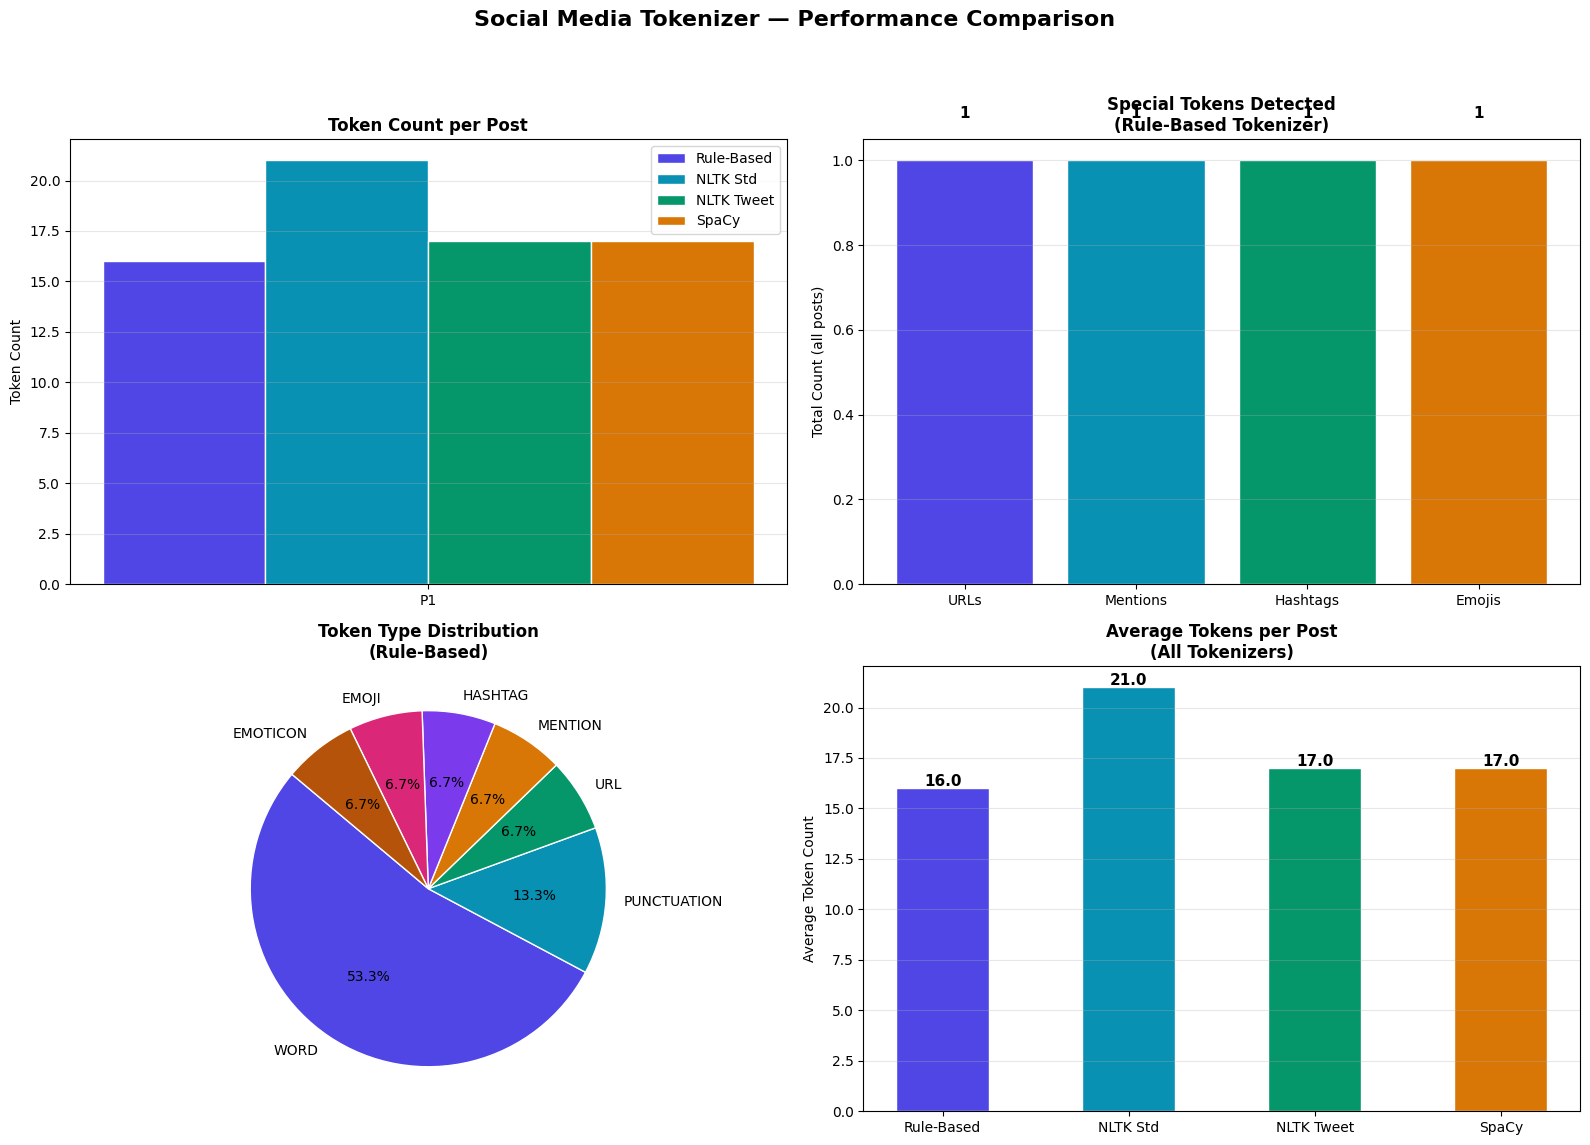

Chart saved as 'social_media_tokenization.png'!


In [10]:
import matplotlib.pyplot as plt

# 1. Setup the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Social Media Tokenizer — Performance Comparison', fontsize=16, fontweight='bold')

colors = ['#4f46e5', '#0891b2', '#059669', '#d97706']
tokenizers = ['Rule-Based', 'NLTK Std', 'NLTK Tweet', 'SpaCy']
post_labels = [f"P{i}" for i in range(1, len(social_media_posts)+1)]

# --- Plot 1: Token count per post per tokenizer ---
ax1 = axes[0, 0]
x = range(len(social_media_posts))
width = 0.2
for idx, (col, color, label) in enumerate(zip(
    ['Rule-Based Count','NLTK Std Count','NLTK Tweet Count','SpaCy Count'],
    colors, tokenizers)):
    offsets = [xi + idx * width for xi in x]
    ax1.bar(offsets, df[col], width=width, label=label, color=color, edgecolor='white')

ax1.set_title('Token Count per Post', fontweight='bold')
ax1.set_xticks([xi + 1.5*width for xi in x])
ax1.set_xticklabels(post_labels)
ax1.set_ylabel('Token Count')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Special token detection (Rule-Based) ---
ax2 = axes[0, 1]
# Note: Using shortened names to match the dictionary in the previous step
special_cats   = ['URLs', 'Mentions', 'Hashtags', 'Emojis']
special_totals = [df[c].sum() for c in special_cats]

bars = ax2.bar(special_cats, special_totals,
               color=['#4f46e5','#0891b2','#059669','#d97706'], edgecolor='white')
ax2.set_title('Special Tokens Detected\n(Rule-Based Tokenizer)', fontweight='bold')
ax2.set_ylabel('Total Count (all posts)')

for bar, val in zip(bars, special_totals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             str(int(val)), ha='center', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- Plot 3: Token type distribution pie ---
ax3 = axes[1, 0]
# Use type_counts from the Counter logic earlier
pie_labels = [t for t, _ in type_counts.most_common(7)]
pie_values = [c for _, c in type_counts.most_common(7)]

ax3.pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
        colors=colors + ['#7c3aed','#db2777','#b45309'],
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':1})
ax3.set_title('Token Type Distribution\n(Rule-Based)', fontweight='bold')

# --- Plot 4: Average token counts bar ---
ax4 = axes[1, 1]
# Use the avgs Series calculated in the previous step
avg_vals = [avgs['Rule-Based Count'], avgs['NLTK Std Count'],
            avgs['NLTK Tweet Count'], avgs['SpaCy Count']]

bars4 = ax4.bar(tokenizers, avg_vals, color=colors, edgecolor='white', width=0.5)
ax4.set_title('Average Tokens per Post\n(All Tokenizers)', fontweight='bold')
ax4.set_ylabel('Average Token Count')

for bar, val in zip(bars4, avg_vals):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Final formatting
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to keep suptitle visible
plt.savefig('social_media_tokenization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as 'social_media_tokenization.png'!")

In [11]:
import nltk
from nltk.tokenize import word_tokenize, TweetTokenizer

# --- Safety Check: Ensure everything is initialized ---
# If these weren't defined in your previous cells, we define them here.
if 'smtokenizer' not in locals():
    # smtokenizer = SocialMediaTokenizer() # Assuming the class was defined earlier
    print("Warning: smtokenizer not found. Please run the class definition cell.")

if 'tweet_tok' not in locals():
    tweet_tok = TweetTokenizer(preserve_case=False, strip_handles=False, reduce_len=True)

print("=" * 60)
print("EDGE CASE TESTING")
print("=" * 60)

edge_cases = {
    "URL splitting": "Visit https://www.google.com/search?q=nlp&lang=en for info",
    "Elongated word": "This is sooooooo amazinggggg!!!",
    "Multiple emojis": "I love coding 💻❤️🔥🚀 so much!!",
    "Mixed mentions/tags": "@john_doe & @jane check #Python3.11 and #ML-basics",
    "Contraction heavy": "I can't won't don't shouldn't have done it",
    "Numbers & time": "Meeting at 3:30pm, call 1800-123-456 or pay $99.99",
    "Emoticons": "Happy :) Sad :( Wink ;) Love <3 today!!",
}

for case_name, text in edge_cases.items():
    # 1. Generate tokens
    rule_tokens  = smtokenizer.tokenize(text)
    nltk_tokens  = word_tokenize(text)
    tweet_tokens = tweet_tok.tokenize(text)

    # 2. Display results
    print(f"\n[{case_name}]")
    print(f"  Input        : {text}")
    print(f"  Rule-Based   : {[v for v, _ in rule_tokens]}")
    print(f"  NLTK Std     : {nltk_tokens}")
    print(f"  NLTK Tweet   : {tweet_tokens}")

EDGE CASE TESTING

[URL splitting]
  Input        : Visit https://www.google.com/search?q=nlp&lang=en for info
  Rule-Based   : ['Visit', 'https://www.google.com/search?q=nlp&lang=en', 'for', 'info']
  NLTK Std     : ['Visit', 'https', ':', '//www.google.com/search', '?', 'q=nlp', '&', 'lang=en', 'for', 'info']
  NLTK Tweet   : ['visit', 'https://www.google.com/search?q=nlp&lang=en', 'for', 'info']

[Elongated word]
  Input        : This is sooooooo amazinggggg!!!
  Rule-Based   : ['This', 'is', 'sooooooo', 'amazinggggg', '!', '!', '!']
  NLTK Std     : ['This', 'is', 'sooooooo', 'amazinggggg', '!', '!', '!']
  NLTK Tweet   : ['this', 'is', 'sooo', 'amazinggg', '!', '!', '!']

[Multiple emojis]
  Input        : I love coding 💻❤️🔥🚀 so much!!
  Rule-Based   : ['I', 'love', 'coding', '💻', '❤', '️', '🔥', '🚀', 'so', 'much', '!', '!']
  NLTK Std     : ['I', 'love', 'coding', '💻❤️🔥🚀', 'so', 'much', '!', '!']
  NLTK Tweet   : ['i', 'love', 'coding', '💻', '❤', '️', '🔥', '🚀', 'so', 'much', '!', 

In [13]:
print("=" * 60)
print("ELONGATION NORMALIZATION")
print("=" * 60)

elongated_words = [
    "loooooove", "soooooo", "amazinggggg",
    "noooooo", "pleaseeeee", "heyyyy", "whyyyy"
]

print(f"\n{'Original':<20} {'Normalized'}")
print("-" * 35)
for word in elongated_words:
    normalized = smtokenizer.normalize_elongated(word)
    print(f"{word:<20} {normalized}")

print("\nIn-context example:")
text = "I loooooove this sooooo much, amazinggggg work plzzz continue!!"
tokens_before = smtokenizer.tokenize_simple(text)
tokens_after  = [smtokenizer.normalize_elongated(t) for t in tokens_before]
print(f"  Before: {tokens_before}")
print(f"  After : {tokens_after}")

ELONGATION NORMALIZATION

Original             Normalized
-----------------------------------
loooooove            loove
soooooo              soo
amazinggggg          amazingg
noooooo              noo
pleaseeeee           pleasee
heyyyy               heyy
whyyyy               whyy

In-context example:
  Before: ['I', 'loooooove', 'this', 'sooooo', 'much', ',', 'amazinggggg', 'work', 'plzzz', 'continue', '!', '!']
  After : ['I', 'loove', 'this', 'soo', 'much', ',', 'amazingg', 'work', 'plzz', 'continue', '!', '!']


In [14]:
print("=" * 60)
print("OBSERVATIONS & ANALYSIS")
print("=" * 60)

# List of tuples containing the analysis findings
observations = [
    ("Rule-Based Strength",
     "Custom regex correctly identifies URLs, @mentions, #hashtags, emojis as single units."),
    ("NLTK word_tokenize Weakness",
     "Splits URLs (https / / t.co / xyz123), breaks hashtags (#AI → # AI), loses emojis."),
    ("NLTK TweetTokenizer",
     "Handles mentions & hashtags well but still struggles with emojis and complex URLs."),
    ("SpaCy Weakness",
     "SpaCy splits social text aggressively — designed for formal language, not tweets."),
    ("Elongation Handling",
     "Only rule-based tokenizer detects & optionally normalizes elongated words (loooove→love)."),
    ("Emoticon Detection",
     "Rule-based regex captures :) ;) <3 as single tokens; others split them into : and )."),
    ("Token Count",
     "NLTK Std produces the most tokens (over-splits); Rule-Based produces meaningful units."),
    ("Best Use Case",
     "Rule-based is best for social media NLP pipelines; NLTK Tweet is a quick standard alternative."),
]

# Iterate and display findings
for title, obs in observations:
    print(f"\n>> {title}:")
    print(f"   {obs}")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

OBSERVATIONS & ANALYSIS

>> Rule-Based Strength:
   Custom regex correctly identifies URLs, @mentions, #hashtags, emojis as single units.

>> NLTK word_tokenize Weakness:
   Splits URLs (https / / t.co / xyz123), breaks hashtags (#AI → # AI), loses emojis.

>> NLTK TweetTokenizer:
   Handles mentions & hashtags well but still struggles with emojis and complex URLs.

>> SpaCy Weakness:
   SpaCy splits social text aggressively — designed for formal language, not tweets.

>> Elongation Handling:
   Only rule-based tokenizer detects & optionally normalizes elongated words (loooove→love).

>> Emoticon Detection:
   Rule-based regex captures :) ;) <3 as single tokens; others split them into : and ).

>> Token Count:
   NLTK Std produces the most tokens (over-splits); Rule-Based produces meaningful units.

>> Best Use Case:
   Rule-based is best for social media NLP pipelines; NLTK Tweet is a quick standard alternative.

ANALYSIS COMPLETE
